# Gap + Regime Conditioned Selection

Combines **Method 3 (Gap/Elbow Detection)** and **Method 5 (Market-Regime Conditioning)**.

## Strategy

Each month the selection pipeline runs in two stages:

### Stage 1 — Market Regime Classification
Compute the 63-day rolling annualised vol of the **NSEI index** (`.NSEI` from `TradingDays.xlsx` Sheet1).  
This determines how aggressive/defensive the selection should be:

| Regime | Market Vol | Gap Multiplier | Min N | Max N | Rationale |
|--------|-----------|---------------|-------|-------|-----------|
| **Calm** | < 12% | 1.5 (tighter) | 5 | 10 | High conviction, concentrate |
| **Normal** | 12–20% | 1.8 | 7 | 15 | Balanced |
| **Stressed** | > 20% | 2.5 (looser) | 10 | 25 | Diversify, relax threshold |

### Stage 2 — Gap/Elbow Detection
Sort the cross-sectional `Vol_Regime_Smooth` signals ascending.  
Compute first-differences (gaps between consecutive tickers) and cut at the first
gap that exceeds `GAP_MULTIPLIER × median_gap`, starting from `MIN_N`:

```
HDFCBANK   0.019  }
BEL        0.022  } small gaps → keep
SBIN       0.032  }
ITC        0.074  ← gap to next = 0.022 > threshold → CUT HERE
──────────────────
KOTAKBANK  0.096  ← excluded
```

### Stage 3 — InvVol Weights
```
w_i = (1 / signal_i) / Σ(1 / signal_j)   calmest stocks get highest weight
```

**Expected behaviour:**
- March 2020 (stressed): portfolio expands to 15–25 stocks at a relaxed gap threshold
- Late 2024 (calm): portfolio concentrates to 5–8 stocks at a tight gap threshold
- The exact count is determined by the natural cluster structure each month — not a fixed N

> **Inputs required:**
> - `ticker_signals_cache.xlsx` — signal history per ticker
> - `mcap_based_universe_202602251340.csv` — market cap universe
> - `data/Universe/TradingDays.xlsx` Sheet1 — NSEI close data for market vol
> - `monthly_low_vol_selection.xlsx` — for fixed-10 comparison in backtest
>
> **Output:** `gap_regime_vol_selection.xlsx`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR           = Path(r'D:\Linear Model')
SIGNAL_CACHE_FILE  = BASE_DIR / 'ticker_signals_cache.xlsx'
MCAP_CSV           = BASE_DIR / 'mcap_based_universe_202602251340.csv'
OUTPUT_FILE        = BASE_DIR / 'gap_regime_vol_selection.xlsx'
TRADING_DAYS_EXCEL = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
BENCHMARK_DIR      = r'D:\Linear Model\data'

# ── Date range ────────────────────────────────────────────────────────────────
SIGNAL_START   = pd.Timestamp('2020-01-01')

# ── Universe ──────────────────────────────────────────────────────────────────
TOP_N_UNIVERSE = 50

# ── Market regime indicator ───────────────────────────────────────────────────
# NSEI (.NSEI) close data from TradingDays.xlsx Sheet1.
# Used to classify market regime each month and condition selection parameters.
MARKET_LOOKBACK = 63    # days for rolling vol (3 months)

# ── Regime thresholds (annualised vol of NSEI) ────────────────────────────────
# Calibrated from NSEI historical vol (avg ~12–15%, spikes to ~30%+ in 2020)
LOW_MKT_VOL    = 0.12   # below this → calm regime
HIGH_MKT_VOL   = 0.20   # above this → stressed regime

# ── Regime-specific parameters ────────────────────────────────────────────────
REGIME_PARAMS = {
    'calm'    : dict(gap_mult=1.5, min_n=5,  max_n=10),
    'normal'  : dict(gap_mult=1.8, min_n=7,  max_n=15),
    'stressed': dict(gap_mult=2.5, min_n=10, max_n=25),
}

print('Configuration loaded.')
print(f'  Market indicator : NSEI (TradingDays.xlsx Sheet1, {MARKET_LOOKBACK}-day rolling vol)')
print(f'  Regime bands     : calm < {LOW_MKT_VOL:.0%} | normal | stressed > {HIGH_MKT_VOL:.0%}')
for r, p in REGIME_PARAMS.items():
    print(f'  {r:<10} : gap_mult={p["gap_mult"]}  N=[{p["min_n"]},{p["max_n"]}]')

Configuration loaded.
  Market indicator : NSEI (TradingDays.xlsx Sheet1, 63-day rolling vol)
  Regime bands     : calm < 12% | normal | stressed > 20%
  calm       : gap_mult=1.5  N=[5,10]
  normal     : gap_mult=1.8  N=[7,15]
  stressed   : gap_mult=2.5  N=[10,25]


## Cell 1 — Load Data

In [2]:
# ── 1a. Load signal cache ─────────────────────────────────────────────────────
print('Loading signal cache...', end=' ')
signals_long = pd.read_excel(SIGNAL_CACHE_FILE, sheet_name='All_Signals_Long')
signals_long['RebalDate'] = pd.to_datetime(signals_long['RebalDate'])

sig_cols = ['RebalDate', 'Ticker', 'Vol_Regime_Smooth', 'Vol_Regime_Monthly']
missing  = [c for c in sig_cols if c not in signals_long.columns]
if missing:
    raise ValueError(f'Columns not found: {missing}')

signals_long = signals_long[sig_cols].dropna(subset=['Vol_Regime_Smooth'], how='all').copy()
print(f'done.  {len(signals_long):,} rows, {signals_long["Ticker"].nunique()} tickers')

# ── 1b. Fast signal lookup ────────────────────────────────────────────────────
signals_long['Period'] = signals_long['RebalDate'].dt.to_period('M')
sig_index = signals_long.set_index(['Ticker', 'Period'])

def get_signal(ticker, rebal_date, lag_months=4):
    for lag in range(lag_months):
        p   = (rebal_date - pd.DateOffset(months=lag)).to_period('M')
        key = (ticker, p)
        if key in sig_index.index:
            row = sig_index.loc[key]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[-1]
            s = row['Vol_Regime_Smooth']
            m = row['Vol_Regime_Monthly']
            s = float(s) if pd.notna(s) and s != 0 else None
            m = float(m) if pd.notna(m) and m != 0 else None
            if s is not None:
                return s, m
    return None, None

print('Signal lookup index built.')

Loading signal cache... done.  13,563 rows, 78 tickers
Signal lookup index built.


In [3]:
# ── 1c. Load market cap CSV and build monthly top-50 universe ─────────────────
print('Loading market cap data...', end=' ')
mcap_df = pd.read_csv(MCAP_CSV, parse_dates=['date'])
print(f'done.  {len(mcap_df):,} rows')

mcap_df.columns = mcap_df.columns.str.lower().str.strip()
mcap_df = mcap_df[['date', 'ticker', 'mcap']].dropna()
mcap_df['ticker'] = mcap_df['ticker'].astype(str).str.strip()
mcap_df = mcap_df[mcap_df['date'] >= SIGNAL_START]

# Snap to month-end — one universe per calendar month
mcap_df['month_end'] = mcap_df['date'].dt.to_period('M').dt.to_timestamp('M')
mcap_monthly = (
    mcap_df.sort_values('date')
    .groupby(['month_end', 'ticker'], as_index=False)['mcap']
    .last()
    .rename(columns={'month_end': 'date'})
)

monthly_universes = {}
for date, grp in mcap_monthly.groupby('date'):
    monthly_universes[pd.Timestamp(date)] = (
        grp.sort_values('mcap', ascending=False)
        .head(TOP_N_UNIVERSE)['ticker'].tolist()
    )

rebal_months = sorted(monthly_universes.keys())
print(f'Monthly universes built: {len(rebal_months)} months, '
      f'{rebal_months[0].date()} to {rebal_months[-1].date()}')

non_me = [d for d in rebal_months if d != d + pd.offsets.MonthEnd(0)]
print(f'All rebalance dates are month-end ✓' if not non_me
      else f'WARNING: {len(non_me)} non-month-end keys')

Loading market cap data... done.  526,104 rows
Monthly universes built: 74 months, 2020-01-31 to 2026-02-28
All rebalance dates are month-end ✓


In [4]:
# ── 1d. Load NSEI from TradingDays.xlsx Sheet1 and compute rolling vol ────────
print('Loading NSEI index from TradingDays.xlsx Sheet1...', end=' ')

_nsei_raw = pd.read_excel(TRADING_DAYS_EXCEL, sheet_name='Sheet1', header=2, usecols=[1, 2])
_nsei_raw.columns = ['Date', 'NSEI']
_nsei_raw['Date'] = pd.to_datetime(_nsei_raw['Date'], errors='coerce')
_nsei_raw = _nsei_raw.dropna(subset=['Date', 'NSEI'])
_nsei_raw['NSEI'] = pd.to_numeric(_nsei_raw['NSEI'], errors='coerce')
_nsei_raw = _nsei_raw.dropna()

market_series = _nsei_raw.set_index('Date')['NSEI'].sort_index()
print(f'done.')
print(f'  Range: {market_series.index[0].date()} to {market_series.index[-1].date()}')
print(f'  Rows : {len(market_series):,}')

# Rolling annualised vol on NSEI
mkt_returns  = market_series.pct_change()
mkt_vol_roll = mkt_returns.rolling(MARKET_LOOKBACK).std() * np.sqrt(252)

def get_market_vol(rebal_date):
    """Return most recent rolling market vol on or before rebal_date."""
    available = mkt_vol_roll.dropna()
    available = available[available.index <= rebal_date]
    return float(available.iloc[-1]) if len(available) > 0 else 0.15  # fallback = normal

def classify_regime(rebal_date):
    """Return 'calm', 'normal', or 'stressed' based on market vol."""
    vol = get_market_vol(rebal_date)
    if vol < LOW_MKT_VOL:
        return 'calm', vol
    elif vol > HIGH_MKT_VOL:
        return 'stressed', vol
    else:
        return 'normal', vol

# ── Show regime distribution across all rebal months ─────────────────────────
print('\nRegime classification across rebalance months:')
regime_counts = {'calm': 0, 'normal': 0, 'stressed': 0}
for dt in rebal_months:
    r, _ = classify_regime(dt)
    regime_counts[r] += 1

total = sum(regime_counts.values())
for r, cnt in regime_counts.items():
    bar = '█' * int(cnt / total * 40)
    params = REGIME_PARAMS[r]
    print(f'  {r:<10} : {cnt:>3} months ({cnt/total:.0%})  {bar}')
    print(f'             gap_mult={params["gap_mult"]}  N=[{params["min_n"]},{params["max_n"]}]')

Loading NSEI index from TradingDays.xlsx Sheet1... done.
  Range: 1995-11-03 to 2026-02-20
  Rows : 7,540

Regime classification across rebalance months:
  calm       :  29 months (39%)  ███████████████
             gap_mult=1.5  N=[5,10]
  normal     :  35 months (47%)  ██████████████████
             gap_mult=1.8  N=[7,15]
  stressed   :  10 months (14%)  █████
             gap_mult=2.5  N=[10,25]


## Cell 2 — Gap + Regime Selection Logic

In [5]:
def find_gap_cutoff(s_sorted, gap_mult, min_n, max_n):
    """
    Find the natural elbow/gap cut point in sorted signal list.

    Parameters
    ----------
    s_sorted  : list of (ticker, signal) sorted ascending by signal
    gap_mult  : cut when gap > gap_mult * median_gap (regime-conditioned)
    min_n     : minimum stocks to select regardless of gaps
    max_n     : maximum stocks; stop scanning beyond this

    Returns
    -------
    int : number of stocks to select (index into s_sorted)

    Algorithm
    ---------
    1. Compute first-differences between consecutive sorted signals.
    2. Compute median gap across the FULL list (not just candidates)
       so the threshold is robust to outliers at the tail.
    3. Scan from min_n onwards; cut at the first gap > gap_mult * median.
    4. If no such gap found, return min(len(s_sorted), max_n).
    """
    n = len(s_sorted)
    if n <= min_n:
        return n

    values    = np.array([sig for _, sig in s_sorted])
    gaps      = np.diff(values)            # length n-1
    median_gap = np.median(gaps)           # global median — robust threshold

    if median_gap <= 0:
        # All signals identical — no discriminating power, use max_n
        return min(n, max_n)

    threshold = gap_mult * median_gap

    # Scan from min_n-1 (gap between position min_n-1 and min_n)
    for i in range(min_n - 1, min(len(gaps), max_n)):
        if gaps[i] > threshold:
            return i + 1    # cut before position i+1

    # No gap large enough found — take up to max_n
    return min(n, max_n)


def build_gap_regime_selection(
    monthly_universes: dict,
    regime_params:     dict = REGIME_PARAMS,
) -> pd.DataFrame:
    """
    For each month:
      1. Classify market regime (calm / normal / stressed)
      2. Retrieve regime-specific (gap_mult, min_n, max_n)
      3. Sort tickers by Vol_Regime_Smooth ascending
      4. Find gap-based cutoff
      5. Assign InvVol weights: w_i = (1/signal_i) / Σ(1/signal_j)

    Returns
    -------
    pd.DataFrame with one row per (month, ticker) scored.
    """
    rows = []

    for rebal_date in sorted(monthly_universes.keys()):
        universe = monthly_universes[rebal_date]
        regime, mkt_vol = classify_regime(rebal_date)
        p = regime_params[regime]
        gap_mult, min_n, max_n = p['gap_mult'], p['min_n'], p['max_n']

        # ── Score every ticker ────────────────────────────────────────────────
        scored = []
        for ticker in universe:
            s_sig, m_sig = get_signal(ticker, rebal_date)
            if s_sig is not None:
                scored.append((ticker, s_sig, m_sig))

        if len(scored) < 3:
            continue

        # Sort ascending by Smooth signal
        scored.sort(key=lambda x: x[1])
        s_sorted = [(t, s) for t, s, _ in scored]
        s_rank   = {t: i + 1 for i, (t, _) in enumerate(s_sorted)}

        # ── Gap detection ─────────────────────────────────────────────────────
        n_select = find_gap_cutoff(s_sorted, gap_mult, min_n, max_n)
        selected_tickers = {t for t, _ in s_sorted[:n_select]}

        # ── InvVol weights ────────────────────────────────────────────────────
        inv_sum = sum(1.0 / s for t, s in s_sorted[:n_select])
        inv_vol_w = {t: (1.0 / s) / inv_sum for t, s in s_sorted[:n_select]}

        # ── Compute gaps for diagnostics ──────────────────────────────────────
        values     = np.array([s for _, s in s_sorted])
        gaps_arr   = np.diff(values)
        median_gap = float(np.median(gaps_arr)) if len(gaps_arr) > 0 else 0.0
        # Gap at the cut point (gap between last selected and first excluded)
        cut_gap = float(gaps_arr[n_select - 1]) if n_select - 1 < len(gaps_arr) else 0.0

        for t, s, m in scored:
            rows.append({
                'RebalDate'     : rebal_date,
                'Ticker'        : t,
                'Smooth_Signal' : round(s, 6),
                'Monthly_Signal': round(m, 6) if m is not None else None,
                'Smooth_Rank'   : s_rank[t],
                'Market_Vol'    : round(mkt_vol, 4),
                'Regime'        : regime,
                'Gap_Mult'      : gap_mult,
                'Min_N'         : min_n,
                'Max_N'         : max_n,
                'Median_Gap'    : round(median_gap, 6),
                'Cut_Gap'       : round(cut_gap, 6),
                'N_Selected'    : n_select,
                'Selected'      : t in selected_tickers,
                'Weight'        : round(inv_vol_w.get(t, 0.0), 6),
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print('  No selections produced.')
        return df

    return df.sort_values(['RebalDate', 'Smooth_Rank']).reset_index(drop=True)


print('find_gap_cutoff() and build_gap_regime_selection() defined.')

find_gap_cutoff() and build_gap_regime_selection() defined.


In [6]:
print('Running gap + regime selection...')
gap_df     = build_gap_regime_selection(monthly_universes)
selected_df = gap_df[gap_df['Selected']].copy()

print(f'\n--- Summary ---')
print(f'  Total scored rows   : {len(gap_df):,}')
print(f'  Total months        : {selected_df["RebalDate"].nunique()}')
print(f'  Total selected rows : {len(selected_df):,}')
print(f'  Avg stocks/month    : {selected_df.groupby("RebalDate").size().mean():.1f}')
print(f'  Min stocks/month    : {selected_df.groupby("RebalDate").size().min()}')
print(f'  Max stocks/month    : {selected_df.groupby("RebalDate").size().max()}')

# ── Per-regime breakdown ──────────────────────────────────────────────────────
print(f'\n--- Per-Regime Breakdown ---')
regime_summary = (
    selected_df.groupby(['Regime', 'RebalDate'])
    .agg(N_Selected=('Ticker', 'count'), Avg_Signal=('Smooth_Signal', 'mean'))
    .reset_index()
    .groupby('Regime')
    .agg(
        Months       = ('RebalDate', 'count'),
        Avg_N        = ('N_Selected', 'mean'),
        Min_N        = ('N_Selected', 'min'),
        Max_N        = ('N_Selected', 'max'),
        Avg_Signal   = ('Avg_Signal', 'mean'),
    )
)
print(regime_summary.round(2).to_string())

# ── Size distribution ─────────────────────────────────────────────────────────
size_dist = selected_df.groupby('RebalDate').size().value_counts().sort_index()
print(f'\n  Portfolio size distribution:')
for n, cnt in size_dist.items():
    bar = '|' * int(cnt / size_dist.max() * 30)
    print(f'    {n:>2} stocks : {cnt:>3} months  {bar}')

Running gap + regime selection...

--- Summary ---
  Total scored rows   : 3,198
  Total months        : 74
  Total selected rows : 744
  Avg stocks/month    : 10.1
  Min stocks/month    : 5
  Max stocks/month    : 25

--- Per-Regime Breakdown ---
          Months  Avg_N  Min_N  Max_N  Avg_Signal
Regime                                           
calm          29   6.90      5     10        0.12
normal        35  10.94      7     15        0.25
stressed      10  16.10     10     25        0.42

  Portfolio size distribution:
     5 stocks :  11 months  ||||||||||||||||||||||
     6 stocks :   2 months  ||||
     7 stocks :  15 months  ||||||||||||||||||||||||||||||
     8 stocks :   7 months  ||||||||||||||
     9 stocks :   4 months  ||||||||
    10 stocks :   9 months  ||||||||||||||||||
    11 stocks :   3 months  ||||||
    12 stocks :   2 months  ||||
    13 stocks :   3 months  ||||||
    14 stocks :   3 months  ||||||
    15 stocks :  10 months  ||||||||||||||||||||
    16 stocks

## Cell 3 — Diagnostics

In [7]:
# ── Compare with original fixed-10 Smooth selection ──────────────────────────
try:
    orig_smooth  = pd.read_excel(BASE_DIR / 'monthly_low_vol_selection.xlsx',
                                  sheet_name='Smooth_Portfolio')
    orig_smooth['RebalDate'] = pd.to_datetime(orig_smooth['RebalDate'])
    orig_smooth_sets = orig_smooth.groupby('RebalDate')['Ticker'].apply(set).to_dict()
    gap_sets         = selected_df.groupby('RebalDate')['Ticker'].apply(set).to_dict()

    comp_rows = []
    for dt in sorted(gap_sets.keys()):
        g   = gap_sets.get(dt, set())
        o   = orig_smooth_sets.get(dt, set())
        r, v = classify_regime(dt)
        comp_rows.append({
            'RebalDate'         : dt,
            'Regime'            : r,
            'Market_Vol'        : round(v, 4),
            'N_Gap'             : len(g),
            'N_Fixed10'         : len(o),
            'Overlap'           : len(g & o),
            'Pct_Match_Fixed10' : round(len(g & o) / max(len(o), 1) * 100, 1),
            'Gap_Only'          : sorted(g - o),
            'Fixed10_Only'      : sorted(o - g),
        })

    comp_df = pd.DataFrame(comp_rows)
    print('--- Gap+Regime vs Fixed-10 Smooth ---')
    print(f'  Avg gap portfolio size  : {comp_df["N_Gap"].mean():.1f} stocks/month')
    print(f'  Avg overlap w Fixed-10  : {comp_df["Overlap"].mean():.1f} stocks/month')
    print(f'  Avg % match vs Fixed-10 : {comp_df["Pct_Match_Fixed10"].mean():.1f}%')
    print()
    print(comp_df[['RebalDate','Regime','Market_Vol','N_Gap','N_Fixed10','Overlap',
                   'Pct_Match_Fixed10']].to_string(index=False))

except FileNotFoundError:
    print('monthly_low_vol_selection.xlsx not found — skipping comparison.')
    comp_df = pd.DataFrame()

--- Gap+Regime vs Fixed-10 Smooth ---
  Avg gap portfolio size  : 10.1 stocks/month
  Avg overlap w Fixed-10  : 5.4 stocks/month
  Avg % match vs Fixed-10 : 54.3%

 RebalDate   Regime  Market_Vol  N_Gap  N_Fixed10  Overlap  Pct_Match_Fixed10
2020-01-31     calm      0.1001      5         10        5               50.0
2020-02-29   normal      0.1484      8          0        0                0.0
2020-03-31 stressed      0.4735     16         10       10              100.0
2020-04-30 stressed      0.5389     17         10       10              100.0
2020-05-31 stressed      0.5607     19          0        0                0.0
2020-06-30 stressed      0.3587     15         10       10              100.0
2020-07-31   normal      0.1988     12         10       10              100.0
2020-08-31   normal      0.1605      8         10        8               80.0
2020-09-30   normal      0.1645     15         10       10              100.0
2020-10-31   normal      0.1611      9          0       

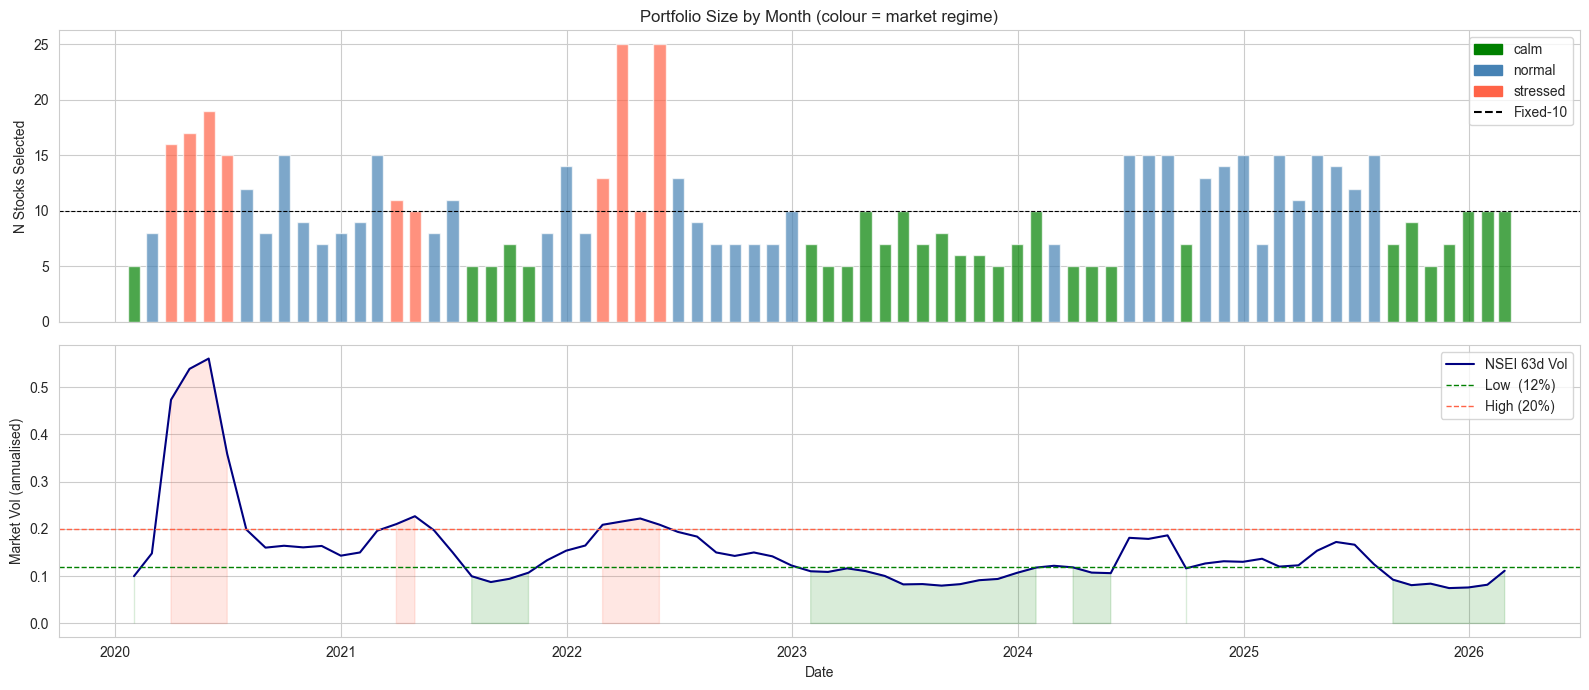


Portfolio size over time:
  Date            N  Regime        MktVol  Bar
  ------------------------------------------------------------
  2020-01-31      5  calm          10.01%  █████░░░░░░░░░░░░░░░░░░░░
  2020-02-29      8  normal        14.84%  ████████░░░░░░░░░░░░░░░░░
  2020-03-31     16  stressed      47.35%  ████████████████░░░░░░░░░
  2020-04-30     17  stressed      53.89%  █████████████████░░░░░░░░
  2020-05-31     19  stressed      56.07%  ███████████████████░░░░░░
  2020-06-30     15  stressed      35.87%  ███████████████░░░░░░░░░░
  2020-07-31     12  normal        19.88%  ████████████░░░░░░░░░░░░░
  2020-08-31      8  normal        16.05%  ████████░░░░░░░░░░░░░░░░░
  2020-09-30     15  normal        16.45%  ███████████████░░░░░░░░░░
  2020-10-31      9  normal        16.11%  █████████░░░░░░░░░░░░░░░░
  2020-11-30      7  normal        16.41%  ███████░░░░░░░░░░░░░░░░░░
  2020-12-31      8  normal        14.35%  ████████░░░░░░░░░░░░░░░░░
  2021-01-31      9  normal        

In [8]:
# ── Portfolio size over time with regime shading ──────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

monthly_sizes  = selected_df.groupby('RebalDate')['N_Selected'].first()
monthly_regime = gap_df.groupby('RebalDate')['Regime'].first()
monthly_mkvol  = gap_df.groupby('RebalDate')['Market_Vol'].first()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

# Top: N selected + regime colouring
regime_color = {'calm': 'green', 'normal': 'steelblue', 'stressed': 'tomato'}
for dt, n in monthly_sizes.items():
    r = monthly_regime.get(dt, 'normal')
    ax1.bar(dt, n, color=regime_color[r], alpha=0.7, width=20)

ax1.axhline(10, color='black', linewidth=0.8, linestyle='--', label='Fixed-10 baseline')
ax1.set_ylabel('N Stocks Selected')
ax1.set_title('Portfolio Size by Month (colour = market regime)', fontsize=12)
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=r) for r, c in regime_color.items()]
legend_handles.append(plt.Line2D([0],[0], color='black', linestyle='--', label='Fixed-10'))
ax1.legend(handles=legend_handles, loc='upper right')

# Bottom: market vol with regime bands
ax2.plot(monthly_mkvol.index, monthly_mkvol.values, color='navy', linewidth=1.5,
         label=f'NSEI {MARKET_LOOKBACK}d Vol')
ax2.axhline(LOW_MKT_VOL,  color='green',  linewidth=1, linestyle='--', label=f'Low  ({LOW_MKT_VOL:.0%})')
ax2.axhline(HIGH_MKT_VOL, color='tomato', linewidth=1, linestyle='--', label=f'High ({HIGH_MKT_VOL:.0%})')
ax2.fill_between(monthly_mkvol.index, 0, monthly_mkvol.values,
                 where=(monthly_mkvol.values > HIGH_MKT_VOL), alpha=0.15, color='tomato')
ax2.fill_between(monthly_mkvol.index, 0, monthly_mkvol.values,
                 where=(monthly_mkvol.values < LOW_MKT_VOL), alpha=0.15, color='green')
ax2.set_ylabel('Market Vol (annualised)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Text summary
print('\nPortfolio size over time:')
print(f'  {"Date":<12}  {"N":>3}  {"Regime":<10}  {"MktVol":>8}  Bar')
print('  ' + '-'*60)
max_n_cfg = max(p['max_n'] for p in REGIME_PARAMS.values())
for dt, n in monthly_sizes.items():
    r   = monthly_regime.get(dt, 'normal')
    vol = monthly_mkvol.get(dt, 0.0)
    bar = '█' * n + '░' * (max_n_cfg - n)
    print(f'  {str(dt.date()):<12}  {n:>3}  {r:<10}  {vol:>8.2%}  {bar}')

## Cell 4 — Build Weight Matrices

In [9]:
# ── InvVol weight matrix ──────────────────────────────────────────────────────
weights_gap_iv = (
    gap_df[gap_df['Selected']]
    .pivot_table(index='RebalDate', columns='Ticker', values='Weight')
    .fillna(0.0)
)
weights_gap_iv.index = pd.to_datetime(weights_gap_iv.index)

# ── Equal-weight matrix ───────────────────────────────────────────────────────
eq_tmp = gap_df[gap_df['Selected']].copy()
eq_tmp['EqWeight'] = eq_tmp.groupby('RebalDate')['Ticker'].transform(lambda x: 1.0 / len(x))
weights_gap_eq = (
    eq_tmp.pivot_table(index='RebalDate', columns='Ticker', values='EqWeight')
    .fillna(0.0)
)
weights_gap_eq.index = pd.to_datetime(weights_gap_eq.index)

# ── Sanity checks ─────────────────────────────────────────────────────────────
for label, w in [('Gap_InvVol', weights_gap_iv), ('Gap_EqualWeight', weights_gap_eq)]:
    rs  = w.sum(axis=1)
    bad = (rs - 1.0).abs() > 0.01
    msg = f'WARNING: {bad.sum()} rows' if bad.any() else 'All rows sum to 1.0 ✓'
    print(f'{label:<20} shape: {w.shape}  |  {msg}')

# ── Weight spread ─────────────────────────────────────────────────────────────
iv_w = gap_df[gap_df['Selected']]['Weight']
eq_w = eq_tmp['EqWeight']
print(f'\n  Weight distribution across all months:')
print(f'  {"":22s}  {"Min":>8}  {"Mean":>8}  {"Max":>8}  {"Std":>8}')
print(f'  {"InvVol":22s}  {iv_w.min():>8.4f}  {iv_w.mean():>8.4f}  {iv_w.max():>8.4f}  {iv_w.std():>8.4f}')
print(f'  {"EqualWeight":22s}  {eq_w.min():>8.4f}  {eq_w.mean():>8.4f}  {eq_w.max():>8.4f}  {eq_w.std():>8.4f}')

# ── Load original fixed-10 matrices for backtest comparison ───────────────────
try:
    SELECTION_EXCEL  = str(BASE_DIR / 'monthly_low_vol_selection.xlsx')
    df_smooth_sel    = pd.read_excel(SELECTION_EXCEL, sheet_name='Smooth_Portfolio')
    df_monthly_sel   = pd.read_excel(SELECTION_EXCEL, sheet_name='Monthly_Portfolio')
    df_smooth_sel['Weight']  = 1.0 / 10.0
    df_monthly_sel['Weight'] = 1.0 / 10.0
    weights_smooth  = df_smooth_sel.pivot_table(index='RebalDate', columns='Ticker', values='Weight').fillna(0)
    weights_monthly = df_monthly_sel.pivot_table(index='RebalDate', columns='Ticker', values='Weight').fillna(0)
    weights_smooth.index  = pd.to_datetime(weights_smooth.index)
    weights_monthly.index = pd.to_datetime(weights_monthly.index)
    print('\nOriginal fixed-10 weight matrices loaded for comparison.')
    orig_available = True
except FileNotFoundError:
    print('monthly_low_vol_selection.xlsx not found.')
    orig_available = False

Gap_InvVol           shape: (74, 59)  |  All rows sum to 1.0 ✓
Gap_EqualWeight      shape: (74, 59)  |  All rows sum to 1.0 ✓

  Weight distribution across all months:
                               Min      Mean       Max       Std
  InvVol                    0.0230    0.0995    0.7095    0.0815
  EqualWeight               0.0400    0.0995    0.2000    0.0425

Original fixed-10 weight matrices loaded for comparison.


## Cell 5 — Save Outputs

In [10]:
portfolio_out  = selected_df[[
    'RebalDate','Ticker','Smooth_Signal','Monthly_Signal','Smooth_Rank',
    'Regime','Market_Vol','Gap_Mult','N_Selected','Weight'
]].copy()

full_scoring_out = gap_df[[
    'RebalDate','Ticker','Smooth_Signal','Smooth_Rank',
    'Regime','Market_Vol','Gap_Mult','Min_N','Max_N',
    'Median_Gap','Cut_Gap','N_Selected','Selected','Weight'
]].copy()

monthly_stats = (
    gap_df.groupby('RebalDate')
    .agg(
        Regime          = ('Regime', 'first'),
        Market_Vol      = ('Market_Vol', 'first'),
        Gap_Mult        = ('Gap_Mult', 'first'),
        Min_N           = ('Min_N', 'first'),
        Max_N           = ('Max_N', 'first'),
        N_Universe      = ('Ticker', 'count'),
        N_Selected      = ('Selected', 'sum'),
        Avg_Sel_Vol     = ('Smooth_Signal', lambda x: x[gap_df.loc[x.index,'Selected']].mean()),
        Avg_Univ_Vol    = ('Smooth_Signal', 'mean'),
        Median_Gap      = ('Median_Gap', 'first'),
        Cut_Gap         = ('Cut_Gap', 'first'),
    )
    .reset_index()
)
monthly_stats['Vol_Premium'] = (monthly_stats['Avg_Univ_Vol'] - monthly_stats['Avg_Sel_Vol']).round(4)

sheets = {
    'Gap_Portfolio'  : portfolio_out,
    'Full_Scoring'   : full_scoring_out,
    'InvVol_Weights' : weights_gap_iv.reset_index(),
    'EqW_Weights'    : weights_gap_eq.reset_index(),
    'Monthly_Stats'  : monthly_stats,
}
if not comp_df.empty:
    sheets['Comparison_vs_Fixed10'] = comp_df

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    for name, df_s in sheets.items():
        df_s.to_excel(writer, sheet_name=name, index=False)

print(f'Saved: {OUTPUT_FILE}')
for name, df_s in sheets.items():
    print(f'  {name:<25} : {len(df_s):,} rows')

Saved: D:\Linear Model\gap_regime_vol_selection.xlsx
  Gap_Portfolio             : 744 rows
  Full_Scoring              : 3,198 rows
  InvVol_Weights            : 74 rows
  EqW_Weights               : 74 rows
  Monthly_Stats             : 74 rows
  Comparison_vs_Fixed10     : 74 rows


## Cell 6 — Sensitivity: Gap Multiplier vs Portfolio Size

Sweep `gap_mult` within each regime to understand how sensitive the portfolio size is.
This helps calibrate the regime boundaries before committing.

In [11]:
from copy import deepcopy

gap_mults  = [1.2, 1.5, 1.8, 2.0, 2.5, 3.0]
test_regimes = ['calm', 'normal', 'stressed']

print('Sensitivity: avg N(min N) per regime vs gap_mult')
print(f'{"":12}', end='')
for gm in gap_mults:
    print(f'  gm={gm}', end='')
print()
print('-' * 75)

for regime in test_regimes:
    base = REGIME_PARAMS[regime]
    marker = ' *' if True else '  '
    print(f'{regime:<12}', end='')
    for gm in gap_mults:
        test_params = deepcopy(REGIME_PARAMS)
        test_params[regime] = dict(gap_mult=gm, min_n=base['min_n'], max_n=base['max_n'])

        trial = build_gap_regime_selection(monthly_universes, regime_params=test_params)
        sel   = trial[trial['Selected'] & (trial['Regime'] == regime)]
        if sel.empty:
            print(f'  {"N/A":>7}', end='')
        else:
            avg_n = sel.groupby('RebalDate').size().mean()
            min_n = sel.groupby('RebalDate').size().min()
            cur = '*' if gm == REGIME_PARAMS[regime]['gap_mult'] else ' '
            print(f'  {avg_n:>5.1f}({min_n}){cur}', end='')
    print(f'  [min={base["min_n"]}, max={base["max_n"]}]')

print(f'\n* = current params.  Format: avg_N(min_N)')
print(f'Current REGIME_PARAMS:')
for r, p in REGIME_PARAMS.items():
    print(f'  {r:<10}: gap_mult={p["gap_mult"]}  N=[{p["min_n"]},{p["max_n"]}]')

Sensitivity: avg N(min N) per regime vs gap_mult
              gm=1.2  gm=1.5  gm=1.8  gm=2.0  gm=2.5  gm=3.0
---------------------------------------------------------------------------
calm            6.4(5)     6.9(5)*    7.4(5)     8.3(5)     8.8(5)     9.2(5)   [min=5, max=10]
normal          9.4(7)     9.8(7)    10.9(7)*   11.0(7)    11.9(7)    13.0(7)   [min=7, max=15]
stressed       10.8(10)    11.5(10)    12.7(10)    14.6(10)    16.1(10)*   16.6(10)   [min=10, max=25]

* = current params.  Format: avg_N(min_N)
Current REGIME_PARAMS:
  calm      : gap_mult=1.5  N=[5,10]
  normal    : gap_mult=1.8  N=[7,15]
  stressed  : gap_mult=2.5  N=[10,25]


---
## Backtest

Runs four portfolios side-by-side:
- **Gap_InvVol** — gap+regime selection, inverse-vol weights
- **Gap_EqualWeight** — same selection, equal weights
- **Smooth_Portfolio** — original fixed-10, equal weights (baseline)
- **Monthly_Portfolio** — original fixed-10, Monthly signal (baseline)

In [12]:
from sqlalchemy import text
import sys

sys.path.insert(0, str(BASE_DIR))
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.db_connections as db

print('Backtest imports loaded.')

Backtest imports loaded.


In [13]:
# ── Universe: union of all four portfolios ────────────────────────────────────
universe_bt = list(
    set(weights_gap_iv.columns)
    | set(weights_gap_eq.columns)
    | (set(weights_smooth.columns) if orig_available else set())
    | (set(weights_monthly.columns) if orig_available else set())
)
print(f'Backtest universe: {len(universe_bt)} unique tickers')

engine = db.DbConnections.get_postgresql_connection(
    config_name=r'D:\Macro Research\db_config.yaml',
    db_name='wm_price_db'
)
engine.connect()

print('Fetching prices from PostgreSQL...')
query = text("""
    SELECT date, ticker, open, high, low, close
    FROM public.merged_historical_data_with_rics
    WHERE ticker = ANY(:tickers)
    ORDER BY date
""")
df_px = pd.read_sql(query, engine, params={'tickers': universe_bt})
df_px['date'] = pd.to_datetime(df_px['date'])

close_df = df_px.pivot(index='date', columns='ticker', values='close').sort_index()
open_df  = df_px.pivot(index='date', columns='ticker', values='open').sort_index()
high_df  = df_px.pivot(index='date', columns='ticker', values='high').sort_index()
low_df   = df_px.pivot(index='date', columns='ticker', values='low').sort_index()

for df in [close_df, open_df, high_df, low_df]:
    df.index.name = 'Date'

print(f'Price data loaded. Shape: {close_df.shape}')

Backtest universe: 61 unique tickers
Fetching prices from PostgreSQL...
Price data loaded. Shape: (6514, 59)


In [14]:
# ── Supplement missing/delisted tickers from CSV ──────────────────────────────
csv_file_path = r'D:\Linear Model\data\Universe\final_eq_2026-02-26-18-30-05_long_format.csv'
ric_to_ticker_map = {'GLSM.NS^D20': 'GSKCONS', 'HDFC.NS^G23': 'HDFC'}

needed = [t for t in ric_to_ticker_map.values() if t in universe_bt]
if needed:
    df_miss = pd.read_csv(csv_file_path)
    df_miss['date']   = pd.to_datetime(df_miss['date'])
    df_miss['ticker'] = df_miss['ric'].map(ric_to_ticker_map)
    df_miss = df_miss[df_miss['ticker'].isin(needed)]

    for price_col, main_df in [('close', close_df), ('open', open_df),
                                 ('high', high_df),  ('low',  low_df)]:
        miss_pivot = df_miss.pivot(index='date', columns='ticker', values=price_col).sort_index()
        miss_pivot.index.name = 'Date'
        # merge into main_df in-place via reassignment
        globals()[f'{price_col}_df'] = main_df.join(miss_pivot, how='outer')

    # Reassign local vars
    close_df, open_df, high_df, low_df = (
        globals()['close_df'], globals()['open_df'],
        globals()['high_df'],  globals()['low_df']
    )
    print(f'Added missing tickers: {needed}')
else:
    print('No missing tickers needed.')

print(f'Final close_df shape: {close_df.shape}')

Added missing tickers: ['GSKCONS', 'HDFC']
Final close_df shape: (6519, 61)


In [15]:
# ── Align with official trading calendar ──────────────────────────────────────
excelReaderObj    = qd.ExcelInputReader()
allTradingDatesDf = excelReaderObj.getTradingDatesDataFrame(
    excelFile=TRADING_DAYS_EXCEL, sheetName='Sheet2', startDate=close_df.index[0]
)
allTradingDatesDf.reset_index(drop=True, inplace=True)

mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, close_df, mergerCol='Date', mergeMethod='left')
openMergedDf  = mergeObj.getMergedBymethodDf(allTradingDatesDf, open_df,  mergerCol='Date', mergeMethod='left')
highMergedDf  = mergeObj.getMergedBymethodDf(allTradingDatesDf, high_df,  mergerCol='Date', mergeMethod='left')
lowMergedDf   = mergeObj.getMergedBymethodDf(allTradingDatesDf, low_df,   mergerCol='Date', mergeMethod='left')

print(f'Prices aligned. Final shape: {closeMergedDf.shape}')

Prices aligned. Final shape: (9546, 61)


In [16]:
def _run_backtest(weights_df, close_df, open_df, high_df, low_df, name):
    """Filter to available tickers, renormalise, run IndexCalculator."""
    valid = [c for c in weights_df.columns if c in close_df.columns]
    miss  = [c for c in weights_df.columns if c not in close_df.columns]
    if miss:
        print(f'  WARNING ({name}): dropping {len(miss)} missing tickers: {miss}')
    w = weights_df[valid].copy()
    w = w.div(w.sum(axis=1), axis=0).fillna(0)

    rebal = w.index
    idx   = close_df.loc[rebal[0]:].index
    obj   = qd.IndexCalculator(idx.values, rebal, w, close_df[w.columns])
    s     = obj.getSimpleNextDayRebalIndex(
        openPriceDf=open_df[w.columns],
        highPriceDf=high_df[w.columns],
        lowPriceDf=low_df[w.columns],
        indexName=name
    )[0]
    print(f'  {name} ✓')
    return s


print('Running backtests...')
df_gap_iv = _run_backtest(weights_gap_iv, closeMergedDf, openMergedDf, highMergedDf, lowMergedDf, 'Gap_InvVol')
df_gap_eq = _run_backtest(weights_gap_eq, closeMergedDf, openMergedDf, highMergedDf, lowMergedDf, 'Gap_EqualWeight')

combined_performance = df_gap_iv.join(df_gap_eq, how='outer').ffill().dropna()

if orig_available:
    df_smooth_bt  = _run_backtest(weights_smooth,  closeMergedDf, openMergedDf, highMergedDf, lowMergedDf, 'Smooth_Portfolio')
    df_monthly_bt = _run_backtest(weights_monthly, closeMergedDf, openMergedDf, highMergedDf, lowMergedDf, 'Monthly_Portfolio')
    combined_performance = (
        combined_performance
        .join(df_smooth_bt, how='outer')
        .join(df_monthly_bt, how='outer')
        .ffill().dropna()
    )

combined_performance = combined_performance.astype(float)
print(f'\nAll portfolios combined. Shape: {combined_performance.shape}')

Running backtests...
  Gap_InvVol ✓
  Gap_EqualWeight ✓
  Smooth_Portfolio ✓
  Monthly_Portfolio ✓

All portfolios combined. Shape: (2213, 4)


In [17]:
# ── Add benchmarks ────────────────────────────────────────────────────────────
import os, glob

benchmark_files = glob.glob(os.path.join(BENCHMARK_DIR, 'scid_Historical_Indices_*.csv'))
benchmark_dfs   = []
for f in benchmark_files:
    df_bm  = pd.read_csv(f)
    scid   = df_bm['_id.scid'].iloc[0]
    df_bm['Date'] = pd.to_datetime(df_bm['_id.date'])
    benchmark_dfs.append(df_bm.set_index('Date')[['index']].rename(columns={'index': scid}))

if benchmark_dfs:
    all_benchmarks = pd.concat(benchmark_dfs, axis=1).sort_index()
    combined_performance = combined_performance.join(all_benchmarks, how='left')
    combined_performance[all_benchmarks.columns] = (
        combined_performance[all_benchmarks.columns].ffill().bfill()
    )
    start_date = combined_performance.index[0]
    for col in all_benchmarks.columns:
        sv = combined_performance.loc[start_date, col]
        combined_performance[col] = combined_performance[col] / sv * 100
    print(f'Added {len(benchmark_dfs)} benchmarks, normalised to 100.')

combined_performance = combined_performance.astype(float)
print(f'Final shape: {combined_performance.shape}')
print(f'Columns: {list(combined_performance.columns)}')

Added 4 benchmarks, normalised to 100.
Final shape: (2213, 8)
Columns: ['Gap_InvVol', 'Gap_EqualWeight', 'Smooth_Portfolio', 'Monthly_Portfolio', 'SCET_0005', 'SCET_0013', 'SCMO_0003', 'SCSB_0003']


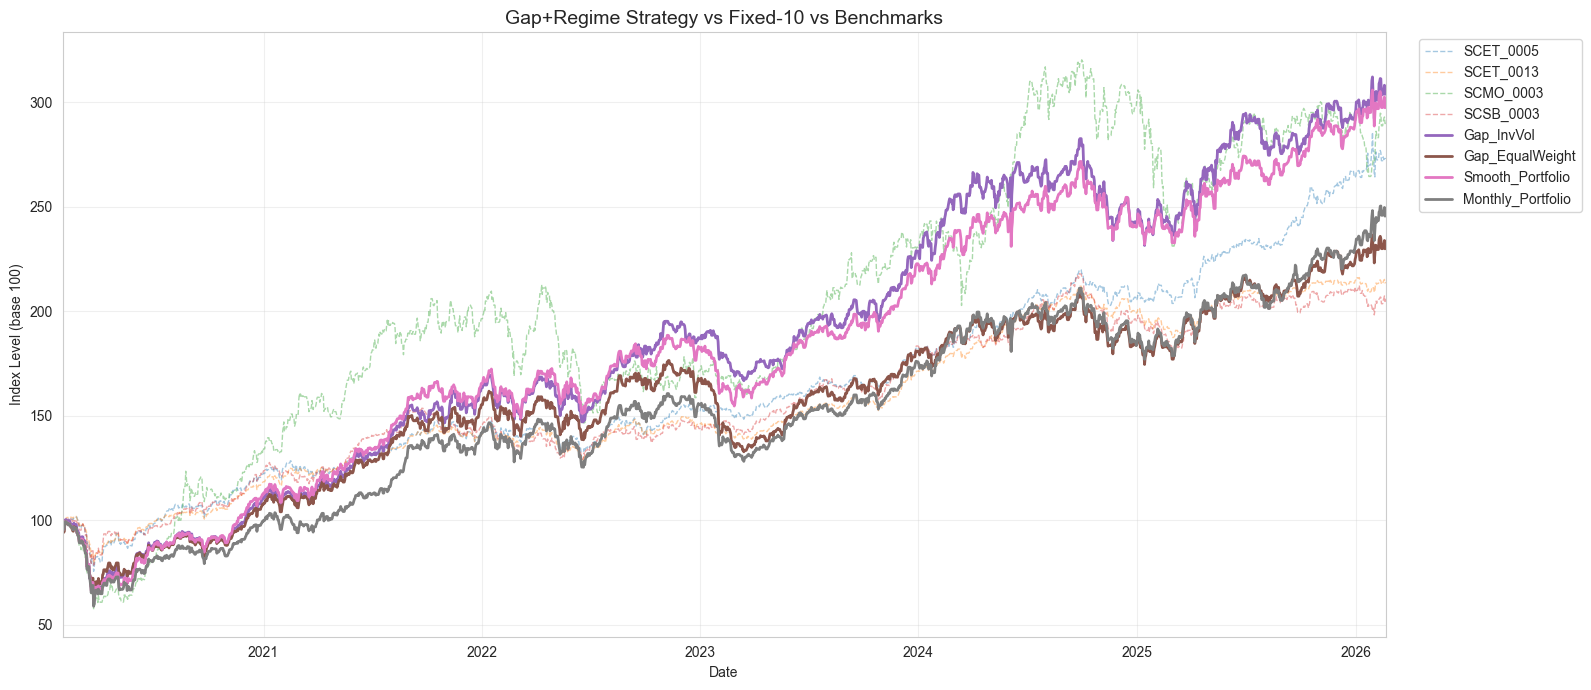

In [18]:
# ── Index level chart ─────────────────────────────────────────────────────────
strategy_cols  = ['Gap_InvVol', 'Gap_EqualWeight', 'Smooth_Portfolio', 'Monthly_Portfolio']
strategy_cols  = [c for c in strategy_cols if c in combined_performance.columns]
benchmark_cols = [c for c in combined_performance.columns if c not in strategy_cols]

plt.figure(figsize=(16, 7))
for col in benchmark_cols:
    combined_performance[col].plot(ax=plt.gca(), linewidth=1.0, alpha=0.4, linestyle='--', label=col)
for col in strategy_cols:
    combined_performance[col].plot(ax=plt.gca(), linewidth=2.0, label=col)

plt.title('Gap+Regime Strategy vs Fixed-10 vs Benchmarks', fontsize=14)
plt.ylabel('Index Level (base 100)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [19]:
# ── Performance metrics ───────────────────────────────────────────────────────
def get_metrics(series):
    analytics    = qd.IndexAnalytics(indexDf=series.to_frame())
    cagr         = float(analytics.getSimpleCGR().iloc[0])
    vol          = float(analytics.getSimpleSTD().iloc[0])
    dr           = analytics.getDownsideDeviation()
    downside     = float(dr.iloc[0] if isinstance(dr, (pd.Series, pd.DataFrame)) else dr)
    daily_ret    = series.pct_change().dropna()
    sharpe       = float((daily_ret.mean() * 252) / (daily_ret.std() * np.sqrt(252)))
    sortino      = float((daily_ret.mean() * 252) / (downside * np.sqrt(252)))
    md           = float((series / series.cummax() - 1.0).min())
    return {'CAGR (%)': cagr*100, 'Ann. Vol (%)': vol*100,
            'Sharpe': sharpe, 'Sortino': sortino, 'Max Drawdown (%)': md*100}

df_metrics = pd.DataFrame({col: get_metrics(combined_performance[col])
                            for col in combined_performance.columns})

col_w = 17
sep   = '=' * (20 + col_w * len(df_metrics.columns))
print(sep)
print(' PORTFOLIO & BENCHMARK PERFORMANCE COMPARISON')
print(sep)
hdr = f" {'Metric':<18} | " + ' | '.join(
    [f"{str(c)[:col_w-2]:>{col_w-2}}" for c in df_metrics.columns])
print(hdr)
print('-' * len(hdr))
for m in df_metrics.index:
    row = f" {m:<18} | " + ' | '.join(
        [f"{df_metrics.loc[m, c]:>{col_w-2}.2f}" for c in df_metrics.columns])
    print(row)
print(sep)

 PORTFOLIO & BENCHMARK PERFORMANCE COMPARISON
 Metric             |      Gap_InvVol | Gap_EqualWeight | Smooth_Portfoli | Monthly_Portfol |       SCET_0005 |       SCET_0013 |       SCMO_0003 |       SCSB_0003
-------------------------------------------------------------------------------------------------------------------------------------------------------------------
 CAGR (%)           |           13.52 |            9.95 |           13.20 |           10.78 |           12.03 |            8.97 |           12.77 |            8.51
 Ann. Vol (%)       |           16.52 |           16.07 |           15.95 |           16.14 |           10.17 |            7.92 |           20.75 |           11.20
 Sharpe             |            0.86 |            0.67 |            0.86 |            0.72 |            1.17 |            1.13 |            0.69 |            0.79
 Sortino            |            1.15 |            0.91 |            1.16 |            0.96 |            1.65 |            1.54 |     

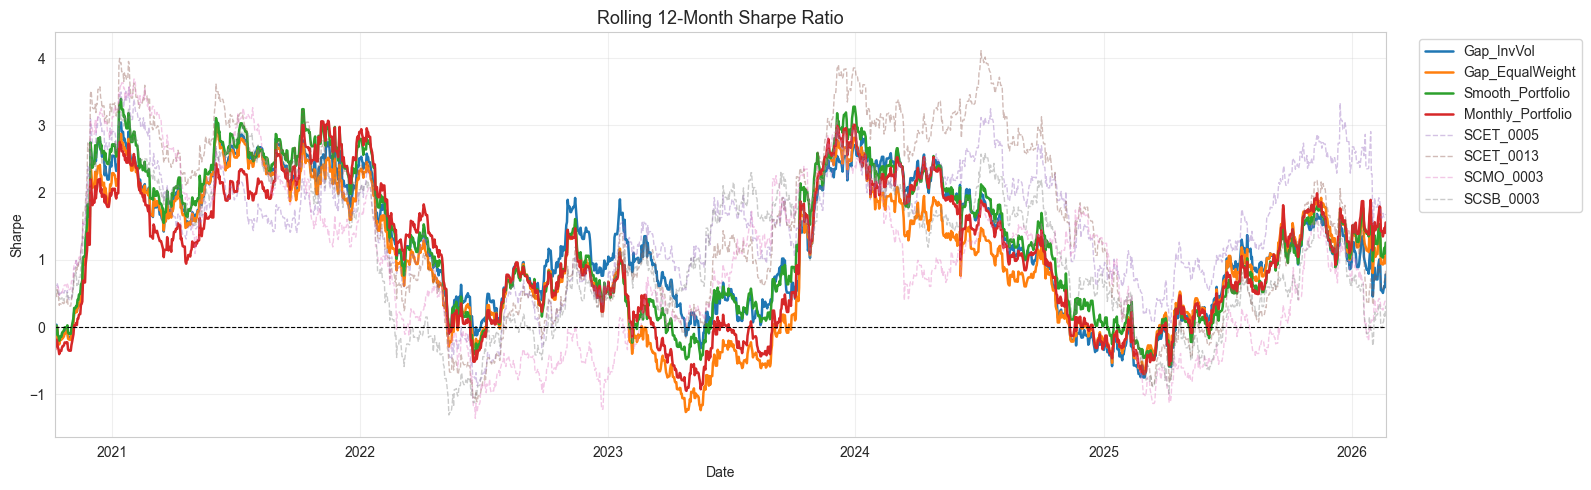

In [20]:
# ── Rolling 12-month Sharpe ───────────────────────────────────────────────────
daily_rets    = combined_performance.pct_change().dropna()
rolling_sharp = (
    daily_rets.rolling(252)
    .apply(lambda x: (x.mean() * 252) / (x.std() * np.sqrt(252)), raw=True)
    .dropna()
)

plt.figure(figsize=(16, 5))
for col in strategy_cols:
    rolling_sharp[col].plot(linewidth=1.8, label=col)
for col in benchmark_cols:
    rolling_sharp[col].plot(linewidth=1.0, alpha=0.4, linestyle='--', label=col)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Rolling 12-Month Sharpe Ratio', fontsize=13)
plt.ylabel('Sharpe')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

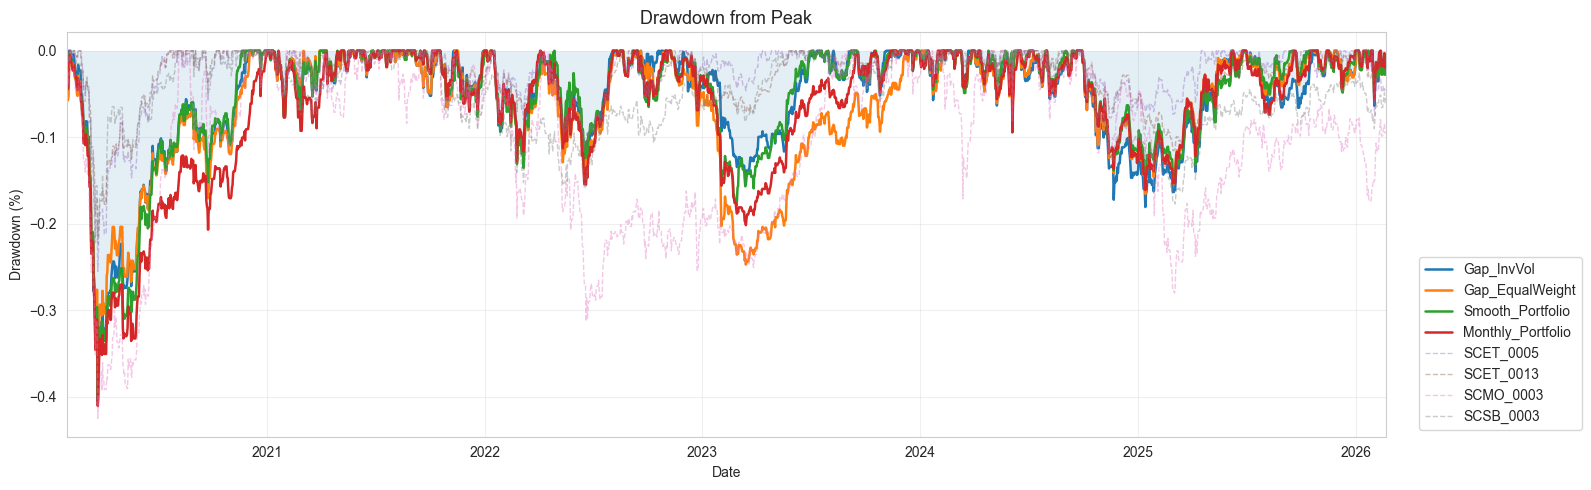

In [21]:
# ── Drawdown chart ─────────────────────────────────────────────────────────────
dd = combined_performance.div(combined_performance.cummax()) - 1.0

plt.figure(figsize=(16, 5))
for col in strategy_cols:
    dd[col].plot(linewidth=1.8, label=col)
for col in benchmark_cols:
    dd[col].plot(linewidth=1.0, alpha=0.4, linestyle='--', label=col)

if 'Gap_InvVol' in dd.columns:
    plt.fill_between(dd.index, dd['Gap_InvVol'], 0, alpha=0.12, label='_nolegend_')

plt.title('Drawdown from Peak', fontsize=13)
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', bbox_to_anchor=(1.02, 0))
plt.tight_layout()
plt.show()

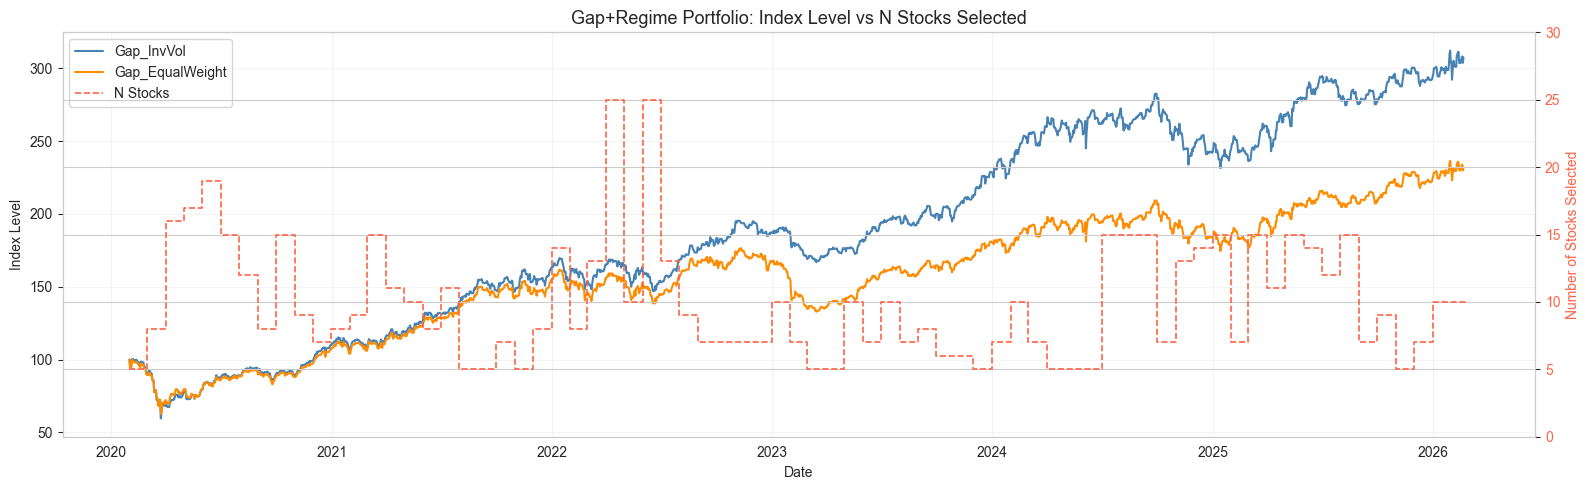

In [22]:
# ── Twin-axis: Gap_InvVol index vs N stocks + market vol ──────────────────────
monthly_sizes  = selected_df.groupby('RebalDate')['N_Selected'].first()
monthly_mkvol  = gap_df.groupby('RebalDate')['Market_Vol'].first()

fig, ax1 = plt.subplots(figsize=(16, 5))

colors = {'Gap_InvVol': 'steelblue', 'Gap_EqualWeight': 'darkorange'}
for col, color in colors.items():
    if col in combined_performance.columns:
        ax1.plot(combined_performance.index, combined_performance[col],
                 color=color, linewidth=1.5, label=col)
ax1.set_ylabel('Index Level')
ax1.set_xlabel('Date')
ax1.grid(True, alpha=0.2)

ax2 = ax1.twinx()
ax2.step(monthly_sizes.index, monthly_sizes.values,
         color='tomato', linewidth=1.2, linestyle='--', where='post', label='N Stocks')
ax2.set_ylabel('Number of Stocks Selected', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, max(p['max_n'] for p in REGIME_PARAMS.values()) + 5)

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper left')

plt.title('Gap+Regime Portfolio: Index Level vs N Stocks Selected', fontsize=13)
plt.tight_layout()
plt.show()